# Imports

In [88]:
import duckdb
import pandas as pd
from dotenv import load_dotenv
import os
import numpy as np
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Connections

In [ ]:
load_dotenv(dotenv_path="../.env")
minio_user = os.getenv("MINIO_ROOT_USER", "minioadmin")
minio_password = os.getenv("MINIO_ROOT_PASSWORD", "minioadmin")
con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")

In [ ]:
con.execute(f"""
    CREATE SECRET IF NOT EXISTS (
        TYPE S3,
        KEY_ID '{minio_user}',
        SECRET '{minio_password}',
        ENDPOINT 'localhost:9000',
        URL_STYLE 'path',
        USE_SSL false
    );
""")

In [ ]:
print("Loading data from Data Lake...")
df = con.execute("SELECT * FROM read_parquet('s3://analytics-data/ml_features.parquet')").df()

Loading data from Data Lake...


In [ ]:
print("\n DATASET ")
print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns (Features): {df.shape[1]}")


 DATASET 
Total Rows: 514,700
Total Columns (Features): 49


In [ ]:
print("\n DATA BREAKDOWN ")
print(df.groupby(['asset_class', 'asset_symbol', 'interval']).size().reset_index(name='Row Count'))


 DATA BREAKDOWN 
   asset_class asset_symbol interval  Row Count
0       Crypto     1000PEPE       1d        847
1       Crypto     1000PEPE       1h      24890
2       Crypto          ADA       1d       1623
3       Crypto          ADA       1h      43518
4       Crypto          ADA        W         62
5       Crypto         AVAX       1d       1442
6       Crypto         AVAX       1h      39173
7       Crypto         AVAX        W         36
8       Crypto          BTC       1d       1981
9       Crypto          BTC       1h      52107
10      Crypto          BTC        W        113
11      Crypto         DOGE       1d       1547
12      Crypto         DOGE       1h      41691
13      Crypto         DOGE        W         51
14      Crypto          DOT       1d       1623
15      Crypto          DOT       1h      43516
16      Crypto          DOT        W         62
17      Crypto         DYDX       1d       1416
18      Crypto         DYDX       1h      38551
19      Crypto        

In [ ]:
print("Loading Feature Statistics...")
stats_df = con.execute("SELECT * FROM read_parquet('s3://analytics-data/feature_statistics.parquet')").df()

Loading Feature Statistics...


In [ ]:
best_features_df = stats_df[stats_df['quality_flag'] == 'PASS'].nlargest(15, 'importance_score')
ml_features_list = best_features_df['feature_name'].tolist()
print("\n ML FEATURE SELECTION ")
print("TOP 15 indicators to train model")
for i, feature in enumerate(ml_features_list, 1):
    print(f"{i}. {feature}")


 ML FEATURE SELECTION 
TOP 15 indicators to train model
1. hl_ratio
2. close_position
3. bb_percentage
4. roc_20
5. stoch_k
6. bb_width
7. rsi_14
8. stoch_d
9. volume_ratio
10. obv
11. roc_10
12. macd_histogram
13. volume
14. macd_signal
15. prev_volume


In [ ]:
symbol = 'BTC'
timeframe = '1d'
clean_data = df[(df['asset_symbol'] == symbol) & (df['interval'] == timeframe)].copy()
clean_data = clean_data.dropna(subset=ml_features_list + ['returns_1d'])
X = clean_data[ml_features_list]
y = np.where(clean_data['returns_1d'] > 0, 1, 0)

In [ ]:
print(f" Separated Data for {symbol} [{timeframe}] ---")
print(f"Total Rows: {len(clean_data)}\n")
display(X.head())

 Separated Data for BTC [1d] ---
Total Rows: 1981



,hl_ratio,close_position,bb_percentage,roc_20,stoch_k,bb_width,rsi_14,stoch_d,volume_ratio,obv,roc_10,macd_histogram,volume,macd_signal,prev_volume
111591,0.038970,0.576617,1.186174,3.587793,83.014572,8.199981,62.836489,89.675056,1.915001,153193.618,5.060879,70.537667,9725.902,-16.038940,5558.201
111592,0.014155,0.546584,1.116429,9.281322,89.435337,9.421770,64.089183,88.864255,0.889259,157514.386,7.190651,87.351897,4320.768,5.799035,9725.902
111593,0.045821,0.652174,1.118380,9.732915,86.237846,11.141184,66.995193,86.229252,1.672036,165847.343,9.260398,104.171552,8332.957,31.841922,4320.768
111594,0.020743,0.432489,0.969848,11.642564,77.299925,11.073411,63.149303,84.324369,1.299720,159295.077,8.391044,101.336433,6552.266,57.176031,8332.957
111595,0.022288,0.485265,0.906019,6.491024,76.776365,11.828403,62.921444,80.104712,1.037789,154133.723,7.055128,93.279225,5161.354,80.495837,6552.266


In [ ]:
print("\nFirst 5 Target Values (1 = UP, 0 = DOWN):")
print(y[:5])


First 5 Target Values (1 = UP, 0 = DOWN):
[1 1 1 0 0]


In [ ]:
def prepare_asset_data(df, symbol, timeframe, features):
    """
    Takes the main dataset and returns clean X (features) and y (target) 
    DataFrames for a specific asset and timeframe.
    """
    clean_data = df[(df['asset_symbol'] == symbol) & (df['interval'] == timeframe)].copy()
    
    if len(clean_data) == 0:
        print(f"Warning: No data found for {symbol} on {timeframe}.")
        return None, None
        
    clean_data = clean_data.dropna(subset=features + ['returns_1d'])
    X = clean_data[features]
    y = pd.Series(np.where(clean_data['returns_1d'] > 0, 1, 0), index=clean_data.index)
    
    return X, y

In [ ]:
X_aapl, y_aapl = prepare_asset_data(df, symbol='AAPL', timeframe='1h', features=ml_features_list)
print(f"extracted {len(X_aapl)} rows of Apple data")

extracted 3192 rows of Apple data


In [ ]:
X_aapl

,hl_ratio,close_position,bb_percentage,roc_20,stoch_k,bb_width,rsi_14,stoch_d,volume_ratio,obv,roc_10,macd_histogram,volume,macd_signal,prev_volume
475556,0.003643,0.600889,1.032018,2.175111,94.345968,2.824403,73.207505,92.559982,1.247968,100238880.0,1.885100,0.226999,8098301.0,0.821489,7602808.0
475557,0.003107,0.482939,0.956074,2.055876,93.778076,3.057303,73.117205,94.439465,0.837094,94785204.0,2.167660,0.251057,5453676.0,0.884253,8098301.0
475558,0.002888,0.796101,0.947359,2.325650,97.784559,3.267672,74.472907,95.302868,0.990380,101301690.0,2.466507,0.266599,6516486.0,0.950903,5453676.0
475559,0.005153,0.223957,0.797537,1.561992,83.601565,3.363737,66.932183,91.721400,1.410019,92051154.0,2.132734,0.208711,9250536.0,1.003081,6516486.0
475560,0.009358,0.262852,0.867166,1.835110,79.092238,3.544356,70.266822,86.826121,2.104602,106805703.0,2.336647,0.198609,14754549.0,1.052733,9250536.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478743,0.010028,0.012087,0.073012,-3.272345,0.387146,4.459678,31.664114,12.623592,1.064719,586118593.0,-2.625981,-0.442416,3280492.0,-1.012804,5452768.0
478744,0.006570,0.484939,0.071776,-3.640356,8.609542,4.607671,30.059509,8.910610,1.087954,582723430.0,-3.126797,-0.494221,3395163.0,-1.136359,3280492.0
478745,0.008002,0.109446,0.020880,-4.008874,2.163088,4.897889,26.727525,3.719925,1.362450,578380218.0,-1.370403,-0.584555,4343212.0,-1.282498,3395163.0
478746,0.003495,0.551934,0.084980,-3.547340,4.696486,5.152085,27.222366,5.156372,0.780847,580873955.0,-1.602079,-0.593477,2493737.0,-1.430867,4343212.0


In [ ]:
def train_and_track_model(X, y, run_name):
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    mlflow.set_tracking_uri("http://localhost:5000")
    mlflow.set_experiment("Financial Predictive Models vers2")
    
    print(f"Starting MLflow tracking for: {run_name}...")
    
    with mlflow.start_run(run_name=run_name):
        mlflow.sklearn.autolog()
        
        model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        
        print(f" Model Trained! Accuracy: {accuracy * 100:.2f}%")
        print(" All data saved to MLflow Dashboard (http://localhost:5000)")
        
    return model

In [90]:
symbol = 'BTC'
timeframe = '1d'
X, y = prepare_asset_data(df, symbol=symbol, timeframe=timeframe, features=ml_features_list)
if X is not None:
    model = train_and_track_model(X, y, run_name=f"{symbol}_{timeframe}")

Starting MLflow tracking for: BTC_1d...


2026/03/13 20:16:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


 Model Trained! Accuracy: 85.14%
 All data saved to MLflow Dashboard (http://localhost:5000)
🏃 View run BTC_1d at: http://localhost:5000/#/experiments/3/runs/0cfa617ddb424b289116792414f2a9d3
🧪 View experiment at: http://localhost:5000/#/experiments/3


Generating Feature Importance visualization...


C:\Users\Manindra\AppData\Local\Temp\ipykernel_4532\3053457453.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance Score', y='Feature', palette='viridis')


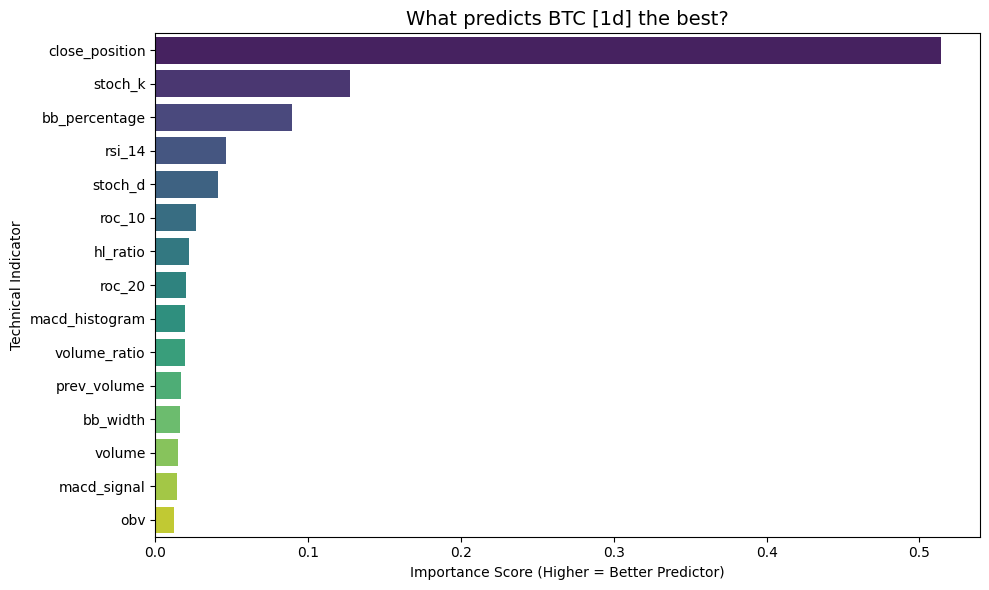

In [91]:
def plot_feature_importance(model, features, symbol, timeframe):
    importances = model.feature_importances_
    
    importance_df = pd.DataFrame({
        'Feature': features,
        'Importance Score': importances
    })
    
    importance_df = importance_df.sort_values(by='Importance Score', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x='Importance Score', y='Feature', palette='viridis')
    
    plt.title(f"What predicts {symbol} [{timeframe}] the best?", fontsize=14)
    plt.xlabel("Importance Score (Higher = Better Predictor)")
    plt.ylabel("Technical Indicator")
    plt.tight_layout()
    plt.show()
print("Generating Feature Importance visualization...")
plot_feature_importance(model, ml_features_list, symbol, timeframe)